In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath("../utils"))
from functions import obtenerCardinalidad, clasificarVariables, distribucionCategoricas, plot_multiple_boxplots, plot_boxplot_grouped

In [17]:
df = pd.read_parquet("../data/chicago_definitivo.parquet")

In [18]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,...,unemployment_rate,hardship_index,median_income,people_of_color_pct,child_opportunity_index,child_opportunity_category,unemployment_category,hardship_category,income_category,people_of_color_category
0,10508693,2016-05-03,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,10.0,24.0,29,...,20.642101,94.022550,33843.809645,95.448671,2.758848,Very Low,High,Very Low,Low,High
1,10508695,2016-05-03,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,3.0,20.0,42,...,16.621749,84.281178,33427.020339,91.581778,14.535765,Very Low,High,Very Low,Low,High
2,10508697,2016-05-03,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,15.0,37.0,25,...,17.040736,85.105219,46440.558367,94.673310,5.768246,Very Low,High,Very Low,Low,High
3,10508698,2016-05-03,BATTERY,SIMPLE,SIDEWALK,False,False,15.0,28.0,25,...,17.040736,85.105219,46440.558367,94.673310,5.768246,Very Low,High,Very Low,Low,High
4,10508699,2016-05-03,THEFT,$500 AND UNDER,RESIDENCE,False,True,15.0,28.0,25,...,17.040736,85.105219,46440.558367,94.673310,5.768246,Very Low,High,Very Low,Low,High


## Clasificación de variables

**Dataset1:** chicago_definitivo.parquet  

**Descripción:** Crímenes cometidos en la ciudad de Chicago (Illinois, USA), enriquecido con datos socioeconómicos por community area.  

**Periodo:** Del 1 de enero de 2014 a 31 de diciembre de 2016

| Nombre del campo | Descripción | Tipo de variable | Importancia inicial |
|---|---|---|---|
| ID | Identificador único del registro. | | |
| Date | Fecha en que ocurrió el incidente. En ocasiones es una estimación aproximada. | | |
| Primary Type | La descripción principal del código IUCR. | | |
| Description | La descripción secundaria del código IUCR, una subcategoría de la descripción principal. | | |
| Location Description | Descripción del lugar donde ocurrió el incidente. | | |
| Arrest | Indica si se realizó una detención. | | |
| Domestic | Indica si el incidente fue de carácter doméstico. | | |
| District | Indica el distrito policial donde ocurrió el incidente. | | |
| Ward | El concejo (distrito del Ayuntamiento) donde ocurrió el incidente. | | |
| Community Area | Indica el área comunitaria donde ocurrió el incidente. Chicago tiene 77 áreas comunitarias. | | |
| Year | Año en que ocurrió el incidente. | | |
| Latitude | La latitud de la ubicación donde ocurrió el incidente. | | |
| Longitude | La longitud de la ubicación donde ocurrió el incidente. | | |
| Location | La ubicación donde ocurrió el incidente. | | |
| neighborhood_name | Nombre del área comunitaria | | |
| unemployment_rate | Porcentaje de desempleo en el área comunitaria | | |
| hardship_index | Índice de calidad de vida | | |
| median_income | Ingresos medios en el área comunitaria | | |
| people_of_color_pct | Porcentaje de personas de color en el área comunitaria | | |
| child_opportunity_index | Índice de oportunidades educativas para la infancia | | |
| child_opportunity_category | Categorización de oportunidades educativas para la infancia | | |
| unemployment_category | Categorización del nivel de desempleo en el área comunitaria | | |
| hardship_category | Categorización del índice de calidad de vida | | |
| income_category | Categorización de los ingresos medios en el área comunitaria | | |
| people_of_color_category | Categorización de de personas de color en el área comunitaria | | |


In [19]:
df_clasificacion = clasificarVariables(df)
df_clasificacion

,Card,Card_pct,Tipo,Clasificada_como
ID,162448,100.00,int64,Numerica Continua
Date,335,0.21,datetime64[us],Numerica Discreta
Primary Type,32,0.02,str,Numerica Discreta
Description,299,0.18,str,Numerica Discreta
Location Description,105,0.06,str,Numerica Discreta
Arrest,2,0.00,bool,Binaria
Domestic,2,0.00,bool,Binaria
District,23,0.01,float64,Numerica Discreta
Ward,50,0.03,float64,Numerica Discreta
Community Area,77,0.05,int64,Numerica Discreta


| Nombre del campo | Descripción | Tipo de variable | Importancia inicial |
|---|---|---|---|
| ID | Identificador único del registro. | Índice único | - |
| Date | Fecha en que ocurrió el incidente. En ocasiones es una estimación aproximada. | Fecha | - |
| Primary Type | La descripción principal del código IUCR. | Numérica Discreta | 0 |
| Description | La descripción secundaria del código IUCR, una subcategoría de la descripción principal. | Numérica Discreta | 3 |
| Location Description | Descripción del lugar donde ocurrió el incidente. | Numérica Discreta | 3 |
| Arrest | Indica si se realizó una detención. | Binaria | 1 |
| Domestic | Indica si el incidente fue de carácter doméstico. | Binaria | 2 |
| District | Indica el distrito policial donde ocurrió el incidente. | Numérica Discreta | 3 |
| Ward | El concejo (distrito del Ayuntamiento) donde ocurrió el incidente. | Numérica Discreta | 3 |
| Community Area | Indica el área comunitaria donde ocurrió el incidente. Chicago tiene 77 áreas comunitarias. | Numérica Discreta | 3 |
| Year | Año en que ocurrió el incidente. | Categórica | 2 |
| Latitude | La latitud de la ubicación donde ocurrió el incidente. | Numérica Continua | 3 |
| Longitude | La longitud de la ubicación donde ocurrió el incidente. | Numérica Continua | 3 |
| Location | La ubicación donde ocurrió el incidente. | Numérica Continua | 2 |
| neighborhood_name | Nombre del área comunitaria | Categórica | 2 |
| unemployment_rate | Porcentaje de desempleo en el área comunitaria | Numérica Discreta | 3 |
| hardship_index | Índice de calidad de vida | Numérica Discreta | 3 |
| median_income | Salario medio en el área comunitaria | Numérica Discreta | 3 |
| people_of_color_pct | Porcentaje de personas de color en el área comunitaria | Numérica Discreta | 3 |
| child_opportunity_index | Índice de oportunidades educativas para la infancia | Numérica Discreta | 3 |
| child_opportunity_category | Categorización de oportunidades educativas para la infancia | Categórica | 1 |
| unemployment_category | Categorización del nivel de desempleo en el área comunitaria | Categórica | 1 |
| hardship_category | Categorización del índice de calidad de vida | Categórica| 1 |
| income_category | Categorización de los ingresos medios en el área comunitaria | Categórica | 1 |
| people_of_color_category | Categorización de de personas de color en el área comunitaria | Categórica | 1 |

## Posiciones medias

In [20]:
df.describe().loc["mean"]

ID                                     9817199.102057
Date                       2014-10-17 16:30:42.549000
District                                    11.196931
Ward                                        22.749194
Community Area                              37.676536
Year                                      2014.389651
Latitude                                    41.909376
Longitude                                  -87.379325
unemployment_rate                           15.688923
hardship_index                              67.985907
median_income                            61501.102706
people_of_color_pct                         77.490389
child_opportunity_index                     25.822575
Name: mean, dtype: object

In [21]:
df.describe().loc["50%"]

ID                                   9804125.5
Date                       2014-10-01 00:00:00
District                                  10.0
Ward                                      23.0
Community Area                            32.0
Year                                    2014.0
Latitude                             41.835484
Longitude                           -87.660347
unemployment_rate                    16.621749
hardship_index                       84.281178
median_income                     49554.028566
people_of_color_pct                  91.581778
child_opportunity_index               14.75901
Name: 50%, dtype: object

In [22]:
df.describe().loc["max"]

ID                                  10550348.0
Date                       2016-05-12 00:00:00
District                                  31.0
Ward                                      50.0
Community Area                            77.0
Year                                    2016.0
Latitude                            420.211265
Longitude                            -8.752685
unemployment_rate                    37.115214
hardship_index                        99.47184
median_income                    146273.528318
people_of_color_pct                  99.166636
child_opportunity_index               88.61183
Name: max, dtype: object

In [23]:
# lista de categóricas

categoricas = [
    'Arrest',
    'Domestic',
    'Year',
    'neighborhood_name',
    'child_opportunity_category',
    'unemployment_category',
    'hardship_category',
    'income_category',
    'people_of_color_category']

In [24]:
df[categoricas].mode().T

,0
Arrest,False
Domestic,False
Year,2014
neighborhood_name,Austin
child_opportunity_category,Very Low
unemployment_category,High
hardship_category,Very Low
income_category,Low
people_of_color_category,Very High


## Frecuencias absolutas

In [25]:
for catego in categoricas:
    print(f"Para {catego}")
    print(df[catego].value_counts())
    print("\n")

Para Arrest
Arrest
False    116056
True      46392
Name: count, dtype: int64


Para Domestic
Domestic
False    137264
True      25184
Name: count, dtype: int64


Para Year
Year
2014    107226
2015     47146
2016      8076
Name: count, dtype: int64


Para neighborhood_name
neighborhood_name
Austin             11052
South Shore         5565
Humboldt Park       5399
Near North Side     5228
North Lawndale      5151
                   ...  
Hegewisch            376
Montclare            338
Forest Glen          275
Burnside             235
Edison Park          159
Name: count, Length: 77, dtype: int64


Para child_opportunity_category
child_opportunity_category
Very Low     89127
Low          31725
Moderate     19037
High         16202
Very High     6357
Name: count, dtype: int64


Para unemployment_category
unemployment_category
High        109846
Moderate     36555
Low          16047
Name: count, dtype: int64


Para hardship_category
hardship_category
Very Low     95595
Low          19400

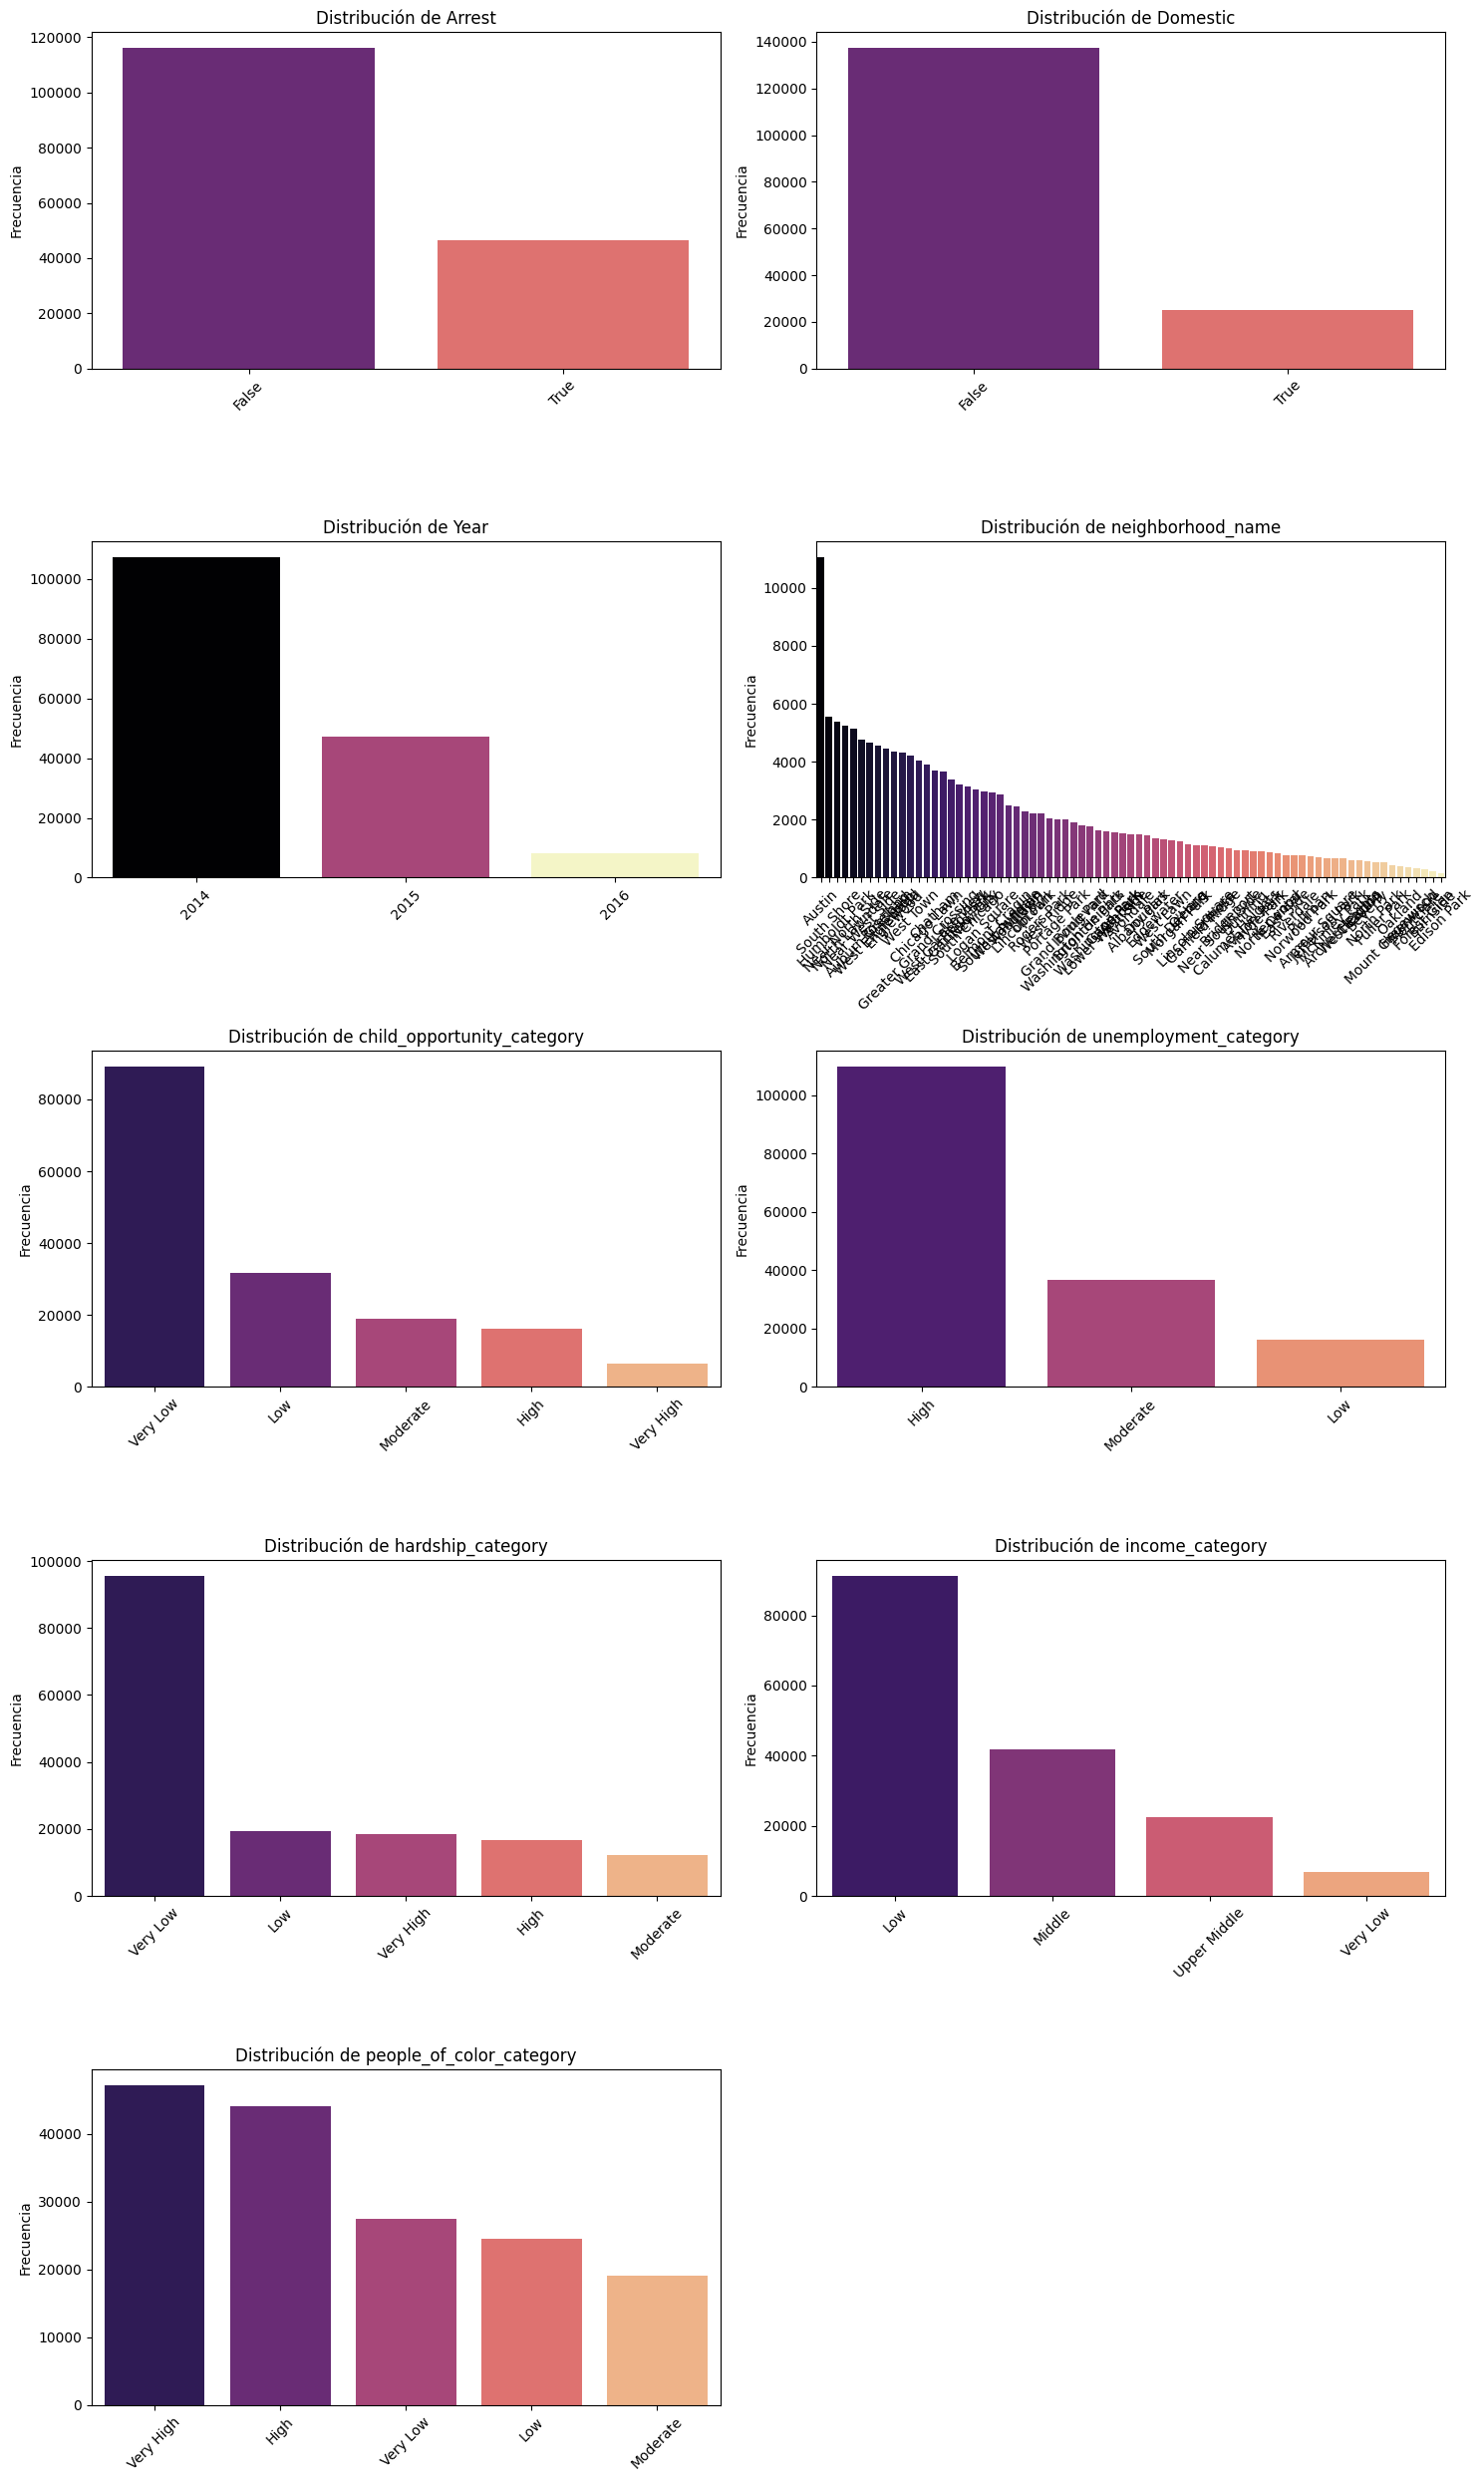

In [26]:
distribucionCategoricas(df, categoricas)

## Frecuencias relativas

In [27]:
for catego in categoricas:
    print(f"Para {catego}")
    print(df[catego].value_counts()/len(df)*100)
    print("\n")

Para Arrest
Arrest
False    71.441938
True     28.558062
Name: count, dtype: float64


Para Domestic
Domestic
False    84.497193
True     15.502807
Name: count, dtype: float64


Para Year
Year
2014    66.006353
2015    29.022210
2016     4.971437
Name: count, dtype: float64


Para neighborhood_name
neighborhood_name
Austin             6.803408
South Shore        3.425712
Humboldt Park      3.323525
Near North Side    3.218261
North Lawndale     3.170861
                     ...   
Hegewisch          0.231459
Montclare          0.208067
Forest Glen        0.169285
Burnside           0.144662
Edison Park        0.097877
Name: count, Length: 77, dtype: float64


Para child_opportunity_category
child_opportunity_category
Very Low     54.864941
Low          19.529326
Moderate     11.718827
High          9.973653
Very High     3.913252
Name: count, dtype: float64


Para unemployment_category
unemployment_category
High        67.619177
Moderate    22.502585
Low          9.878238
Name: count, 

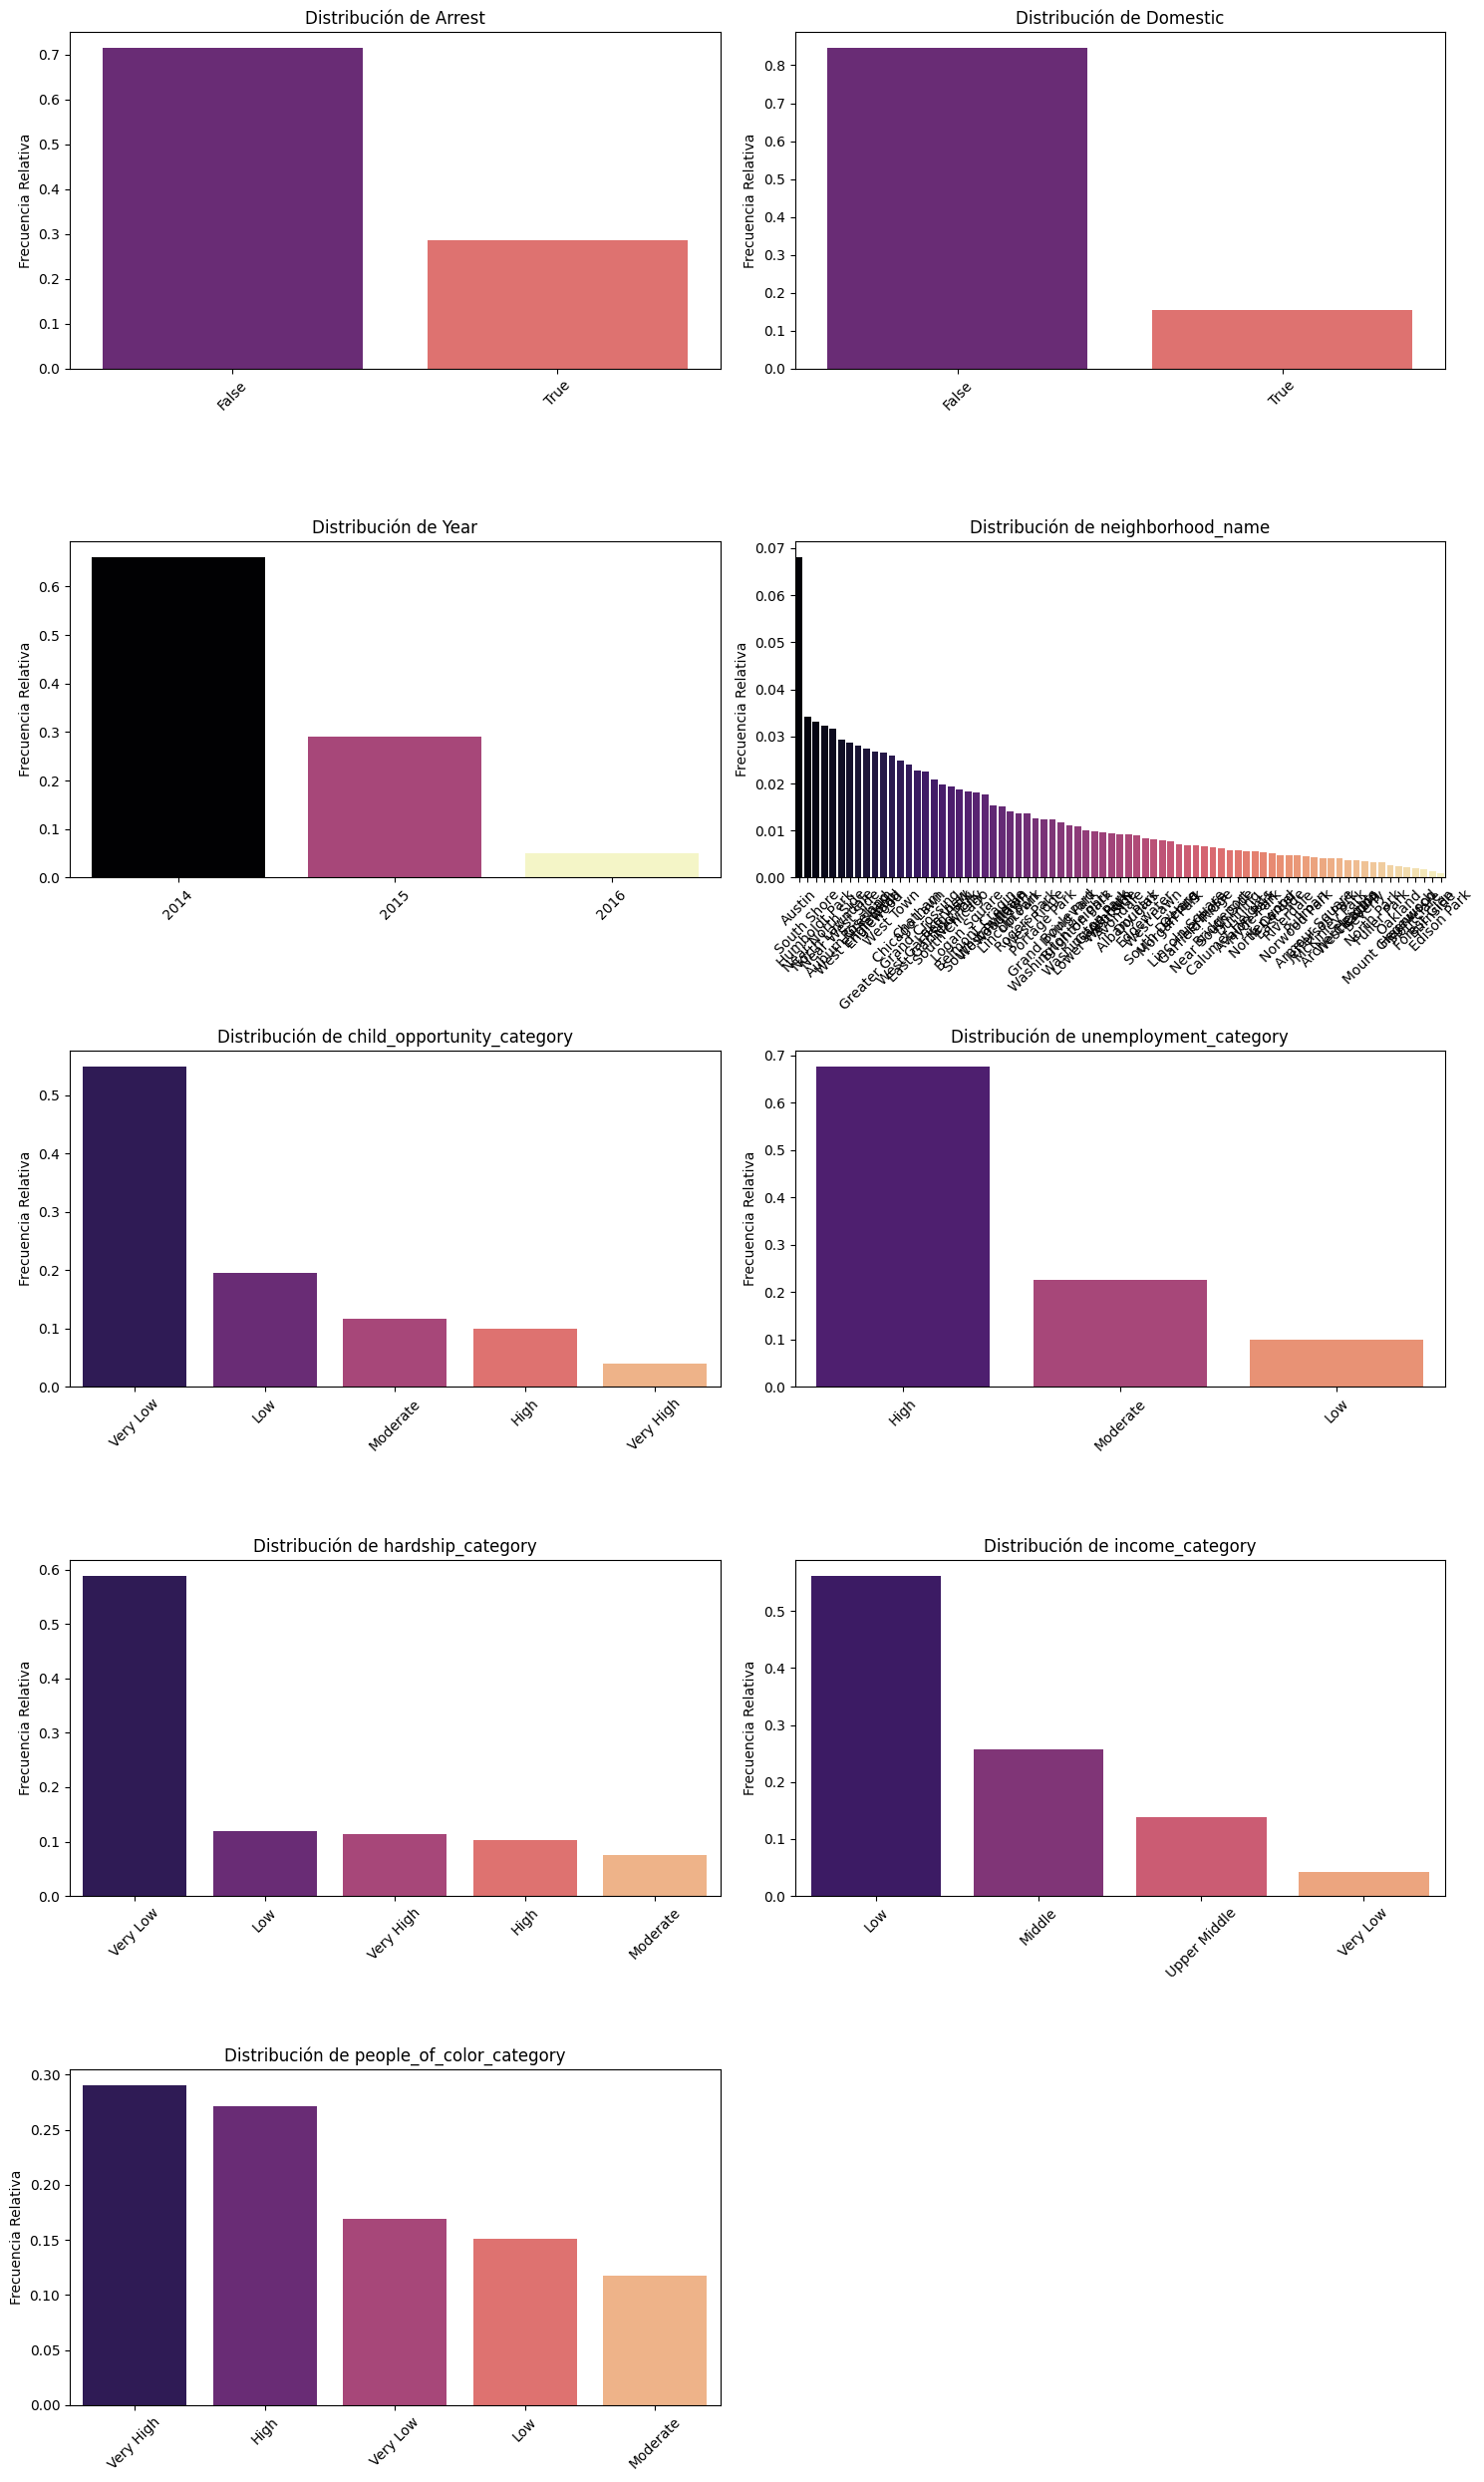

In [28]:
distribucionCategoricas(df, categoricas, relativa=True)

## Percentiles y BoxPlots

In [29]:
# Genero lista de variables numéricas
numericas = []
lista = df.columns.to_list()

for i in lista:
    if i not in categoricas:
        numericas.append(i)

# Elimino los valores que no son index o fecha
del numericas[0:2]

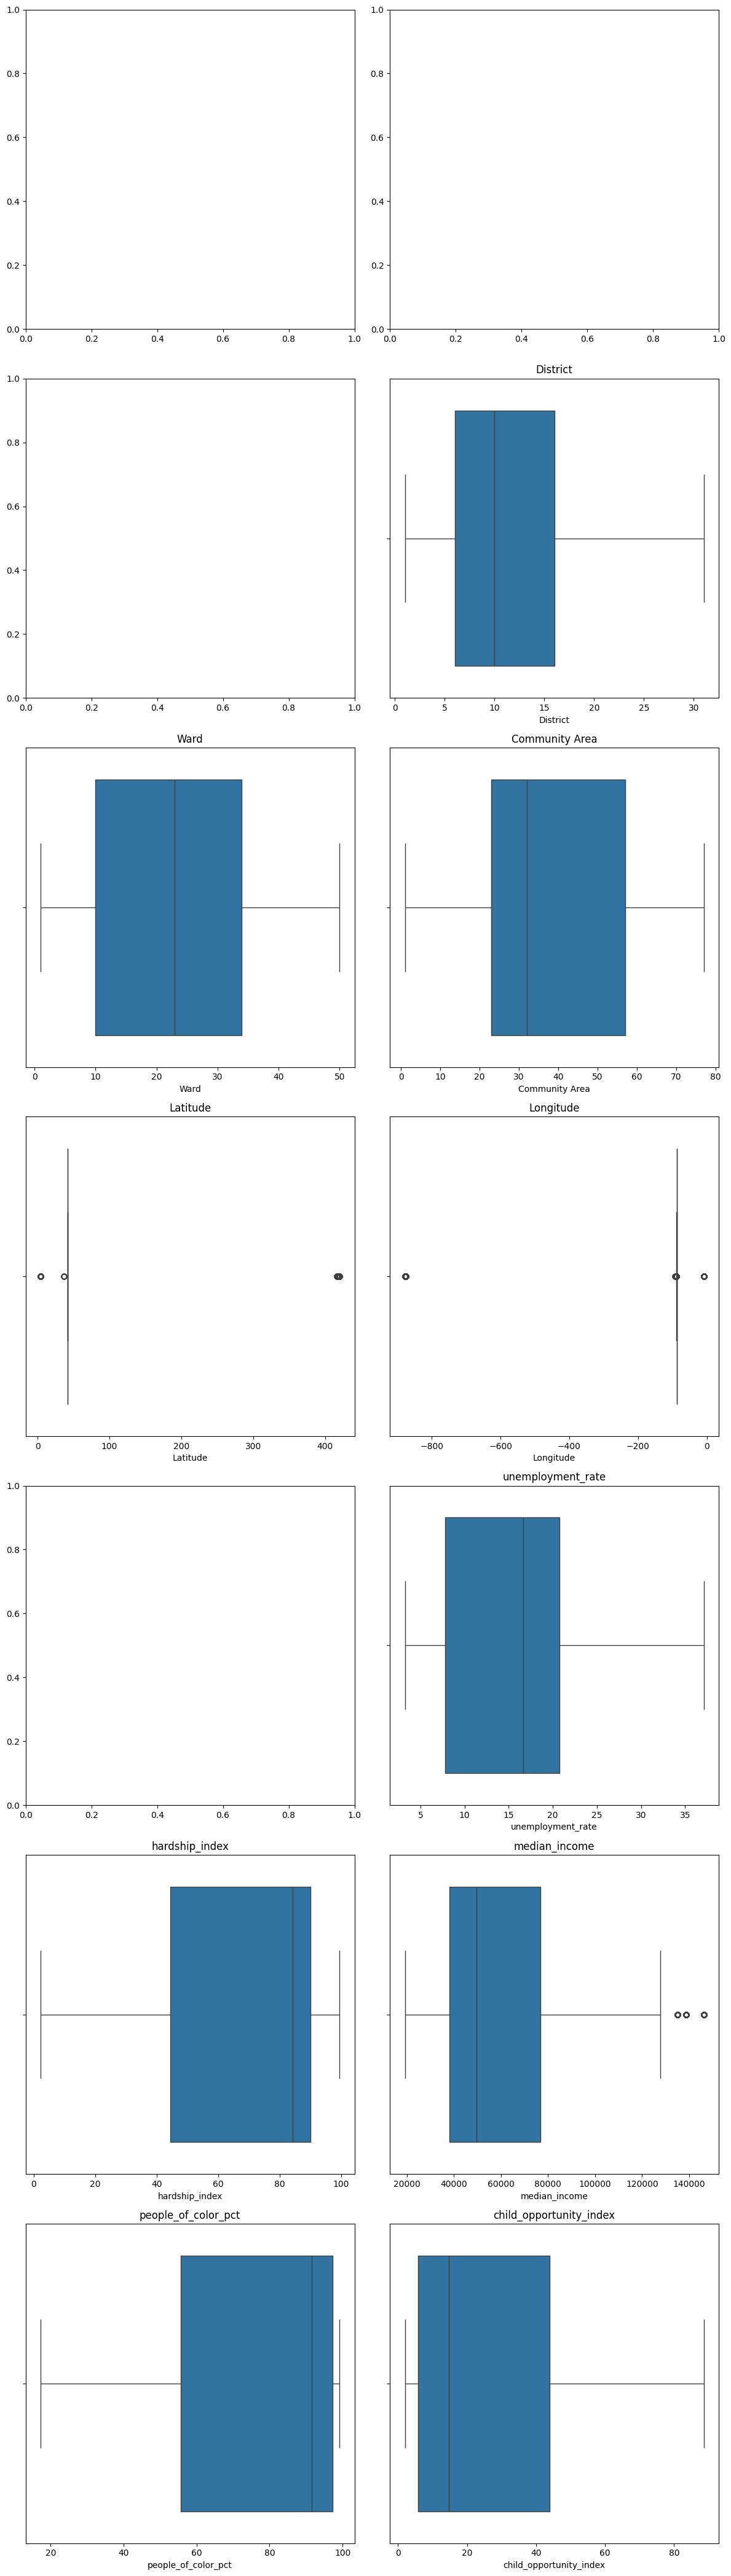

In [30]:
plot_multiple_boxplots(df, numericas)

## Rangos

In [31]:
df.describe().loc["max"] - df.describe().loc["min"]

ID                                10528034.0
Date                       862 days 00:00:00
District                                30.0
Ward                                    49.0
Community Area                          76.0
Year                                     2.0
Latitude                          416.046752
Longitude                         869.622119
unemployment_rate                  33.890865
hardship_index                     97.235667
median_income                  127189.656128
people_of_color_pct                81.900758
child_opportunity_index            86.605465
dtype: object